In [73]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pypsa
import yaml
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

RES  = ROOT / 'results' / 'res3h_2023_2025'
PROC = ROOT / 'data' / 'processed'

plt.rcParams['figure.figsize'] = (15, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ZONES = ['SE-N', 'SE-S', 'NO-N', 'NO-S', 'DK', 'FI']

with open(ROOT / 'config' / 'zones.yaml') as f:
    cfg = yaml.safe_load(f)

# Ladda nätverk
n = pypsa.Network()
n.import_from_netcdf(RES / 'network.nc')

# Ladda CSV-resultat
dispatch  = pd.read_csv(RES / 'dispatch_generators.csv', index_col=0, parse_dates=True)
hydro_d   = pd.read_csv(RES / 'dispatch_hydro.csv',      index_col=0, parse_dates=True)
hydro     = hydro_d   # alias
soc       = pd.read_csv(RES / 'hydro_soc.csv',           index_col=0, parse_dates=True)
spill     = pd.read_csv(RES / 'hydro_spill.csv',         index_col=0, parse_dates=True)
flows     = pd.read_csv(RES / 'flows.csv',               index_col=0, parse_dates=True)
prices    = pd.read_csv(RES / 'prices.csv',              index_col=0, parse_dates=True)
mkt_price = pd.read_parquet(PROC / 'market_price.parquet')['price_eur_mwh']

# Faktisk last (tz-naiv, reindexad till snapshots)
load_raw = pd.read_parquet(PROC / 'load.parquet')
load_raw.index = pd.to_datetime(load_raw.index, utc=True).tz_localize(None)
load = load_raw.reindex(dispatch.index)

print(f'Tidssteg: {len(n.snapshots)}  ({n.snapshots[0]} – {n.snapshots[-1]})')
print(f'Zoner: {ZONES}')
print(f'Slack totalt: {dispatch.filter(like="slack").sum().sum()/1e3:.1f} GWh  (bör vara 0)')

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks


Tidssteg: 8768  (2023-01-01 00:00:00 – 2025-12-31 21:00:00)
Zoner: ['SE-N', 'SE-S', 'NO-N', 'NO-S', 'DK', 'FI']
Slack totalt: 0.0 GWh  (bör vara 0)


## 1. Modellpriser vs verkliga spotpriser

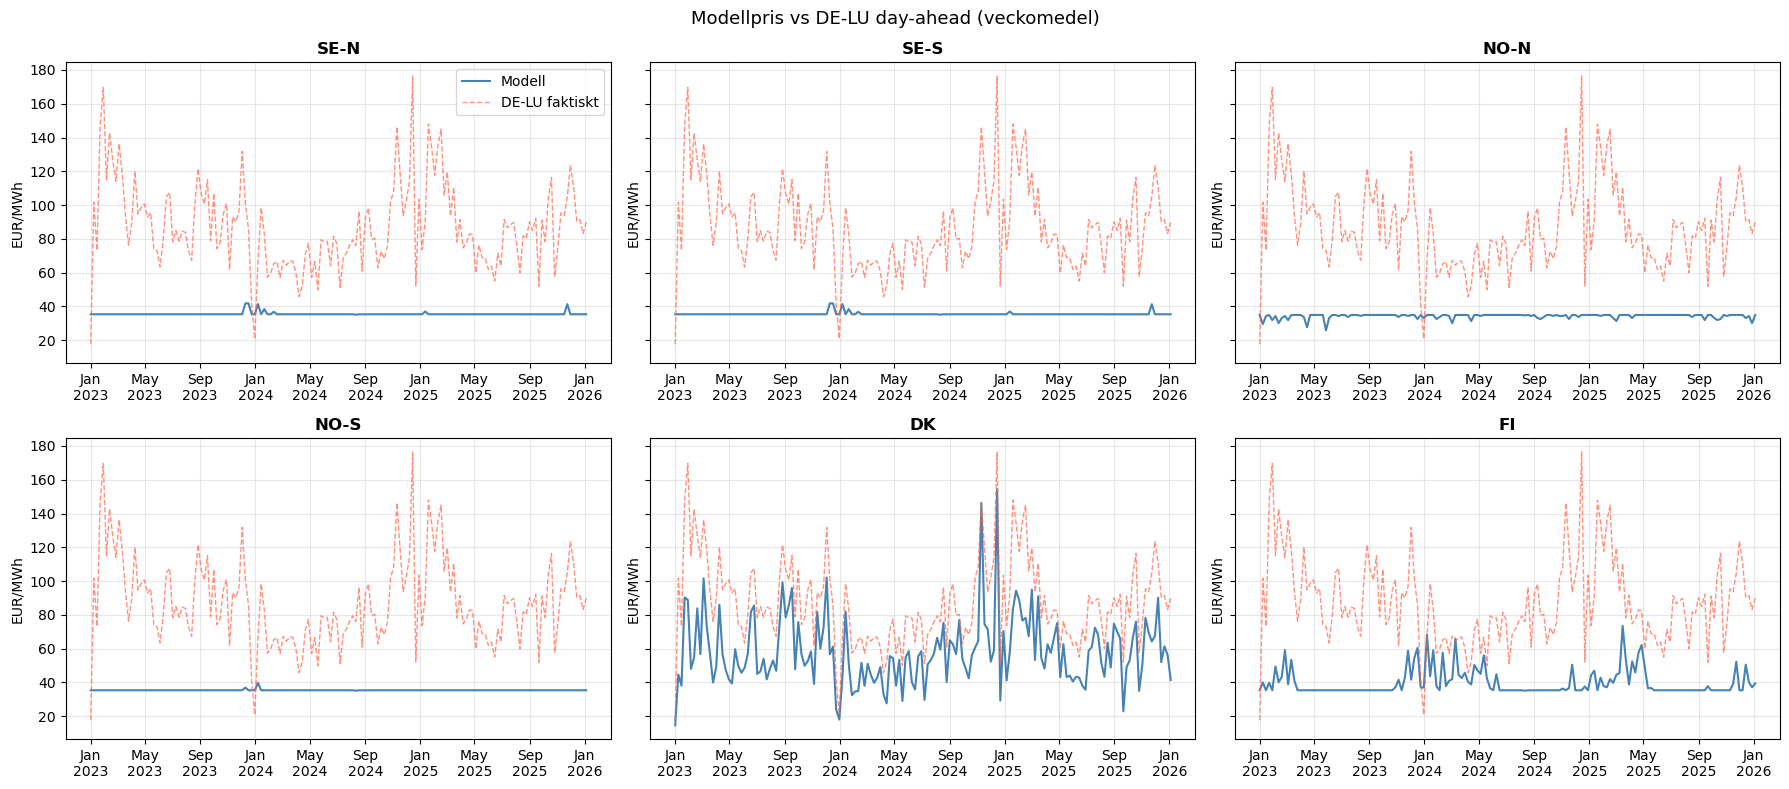

In [74]:
# Modellpris (skuggpris) vs DE-LU day-ahead — veckomedel
mkt_w = mkt_price.resample('W').mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
for ax, zone in zip(axes.flat, ZONES):
    p = prices[zone].resample('W').mean()
    ax.plot(p.index, p.values, lw=1.5, color='steelblue', label='Modell')
    ax.plot(mkt_w.index, mkt_w.values, lw=1, color='tomato', ls='--', alpha=0.7, label='DE-LU faktiskt')
    ax.set_title(zone, fontweight='bold')
    ax.set_ylabel('EUR/MWh')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[0, 0].legend()
plt.suptitle('Modellpris vs DE-LU day-ahead (veckomedel)', fontsize=13)
plt.tight_layout()

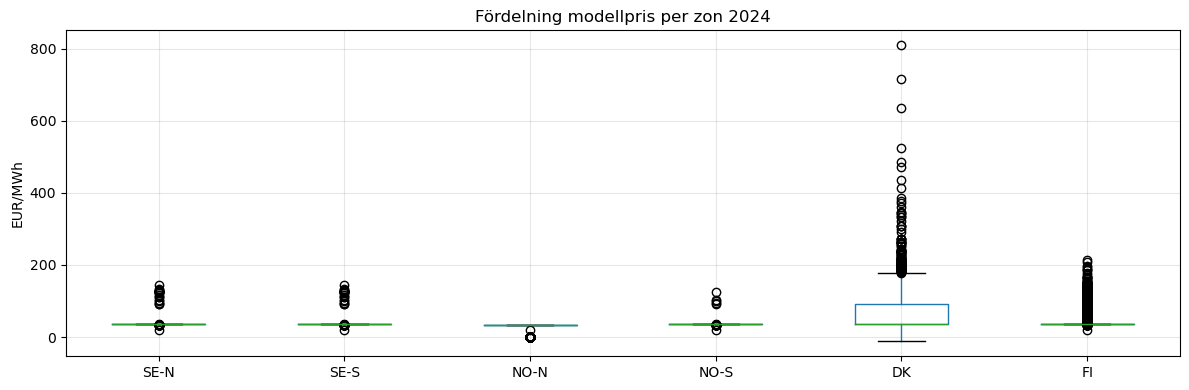

In [75]:
# Prisfördelning per zon
fig, ax = plt.subplots(figsize=(12, 4))
prices[ZONES].boxplot(ax=ax)
ax.set_ylabel('EUR/MWh')
ax.set_title('Fördelning modellpris per zon 2024')
plt.tight_layout()

In [76]:
# Prisstatistik per zon och år
for year in [2023, 2024, 2025]:
    print(f'\n{year}:')
    print(f"  {'Zon':<8} {'Medel':>8} {'Min':>8} {'Max':>8}  {'pris=0':>8}  {'DE-LU':>8}")
    yr_mkt = mkt_price[str(year)].mean()
    for zone in ZONES:
        p = prices[zone][str(year)]
        print(f"  {zone:<8} {p.mean():>7.1f}  {p.min():>7.1f}  {p.max():>7.1f}   "
              f"{(p < 1).mean()*100:>6.1f}%   {yr_mkt:>7.1f}")


2023:
  Zon         Medel      Min      Max    pris=0     DE-LU
  SE-N        35.5     34.9    128.4      0.0%      95.2
  SE-S        35.5     34.9    128.4      0.0%      95.2
  NO-N        34.0      1.0     34.9      0.0%      95.2
  NO-S        35.3     34.9    124.9      0.0%      95.2
  DK          60.4    -12.1    308.0      3.1%      95.2
  FI          38.7     34.9    213.7      0.0%      95.2

2024:
  Zon         Medel      Min      Max    pris=0     DE-LU
  SE-N        35.5     20.0    132.5      0.0%      78.5
  SE-S        35.5     20.0    132.5      0.0%      78.5
  NO-N        34.4      1.0     34.9      0.0%      78.5
  NO-S        35.4     20.0    102.6      0.0%      78.5
  DK          54.9     -5.2    809.8      4.3%      78.5
  FI          40.4     20.0    187.8      0.0%      78.5

2025:
  Zon         Medel      Min      Max    pris=0     DE-LU
  SE-N        35.4     34.9    145.8      0.0%      89.3
  SE-S        35.4     34.9    145.8      0.0%      89.3
  NO-N 

## 2. Reservoarnivåer (hydro SoC)

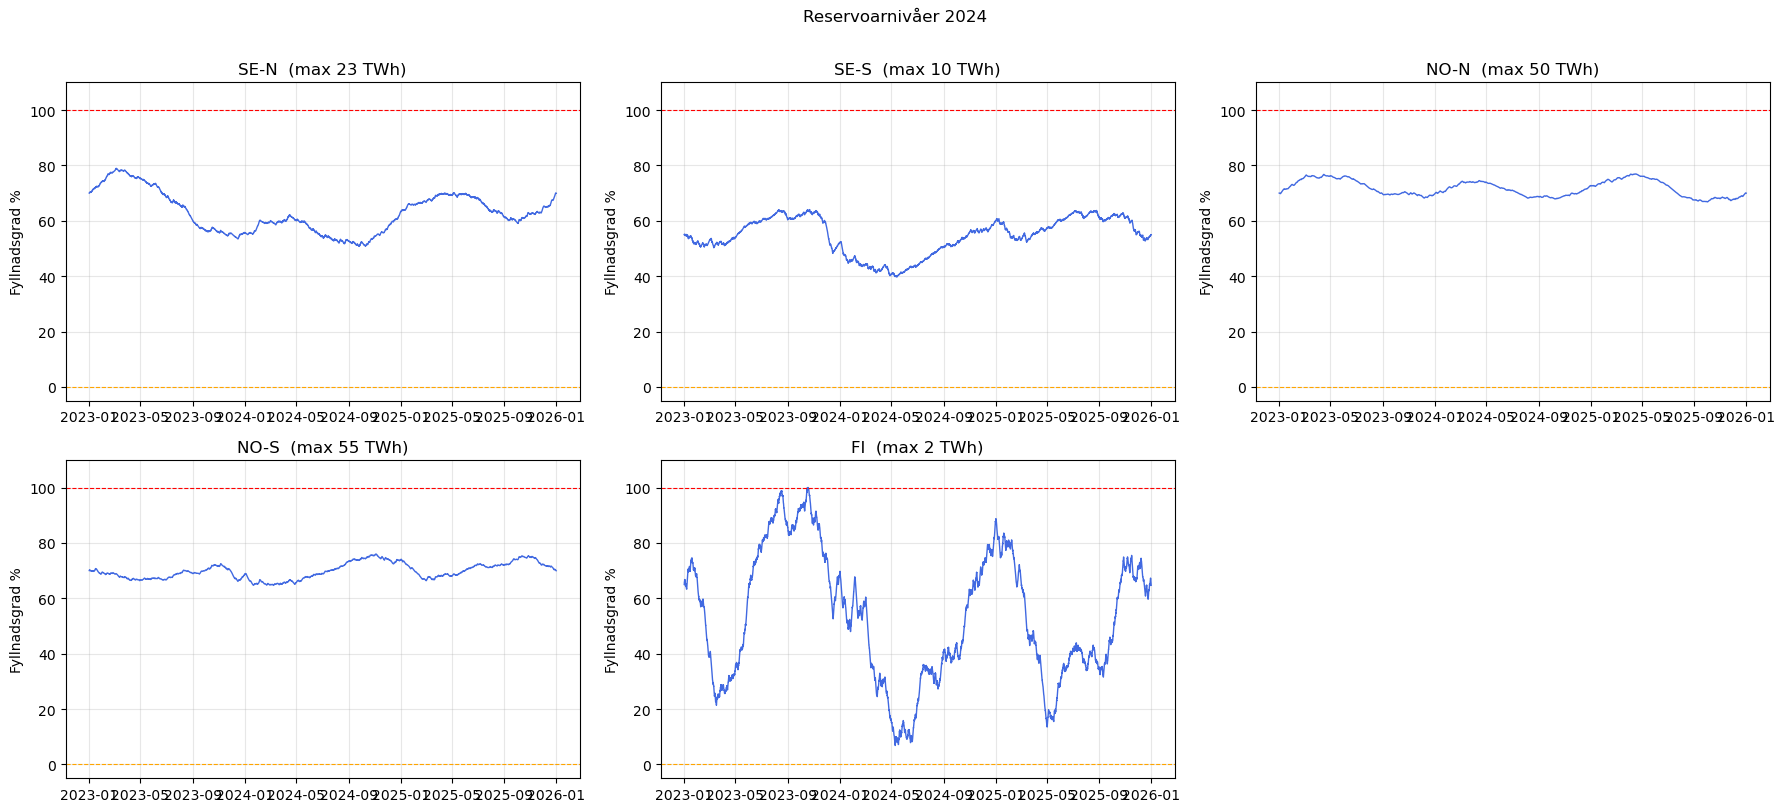

In [77]:
# SoC i % av max kapacitet
import yaml
with open(ROOT / 'config' / 'zones.yaml') as f:
    cfg = yaml.safe_load(f)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
hydro_zones = [z for z in ZONES if cfg['zones'][z]['hydro_p_nom_mw'] > 0]

for ax, zone in zip(axes.flat, hydro_zones):
    p_nom  = cfg['zones'][zone]['hydro_p_nom_mw']
    max_h  = cfg['zones'][zone]['hydro_max_hours']
    max_e  = p_nom * max_h  # MWh
    col    = f'{zone} hydro'
    if col in soc.columns:
        soc_pct = soc[col] / max_e * 100
        ax.plot(soc_pct.index, soc_pct.values, lw=1, color='royalblue')
        ax.axhline(100, color='red', ls='--', lw=0.8, label='Max')
        ax.axhline(0,   color='orange', ls='--', lw=0.8, label='Min')
        ax.set_ylim(-5, 110)
        ax.set_title(f'{zone}  (max {max_e/1e6:.0f} TWh)')
        ax.set_ylabel('Fyllnadsgrad %')

for ax in axes.flat[len(hydro_zones):]:
    ax.set_visible(False)

plt.suptitle('Reservoarnivåer 2024', y=1.01)
plt.tight_layout()

In [59]:
# Spill — hur mycket vatten spills?
total_spill = spill.sum()
print('Total spill (MWh):')
for col, val in total_spill.items():
    if val > 0:
        print(f'  {col}: {val/1e6:.2f} TWh')
if (total_spill == 0).all():
    print('  Inget spill — modellen klarar sig utan!')

Total spill (MWh):
  Inget spill — modellen klarar sig utan!


## 3. Dispatch — stackade area-grafer

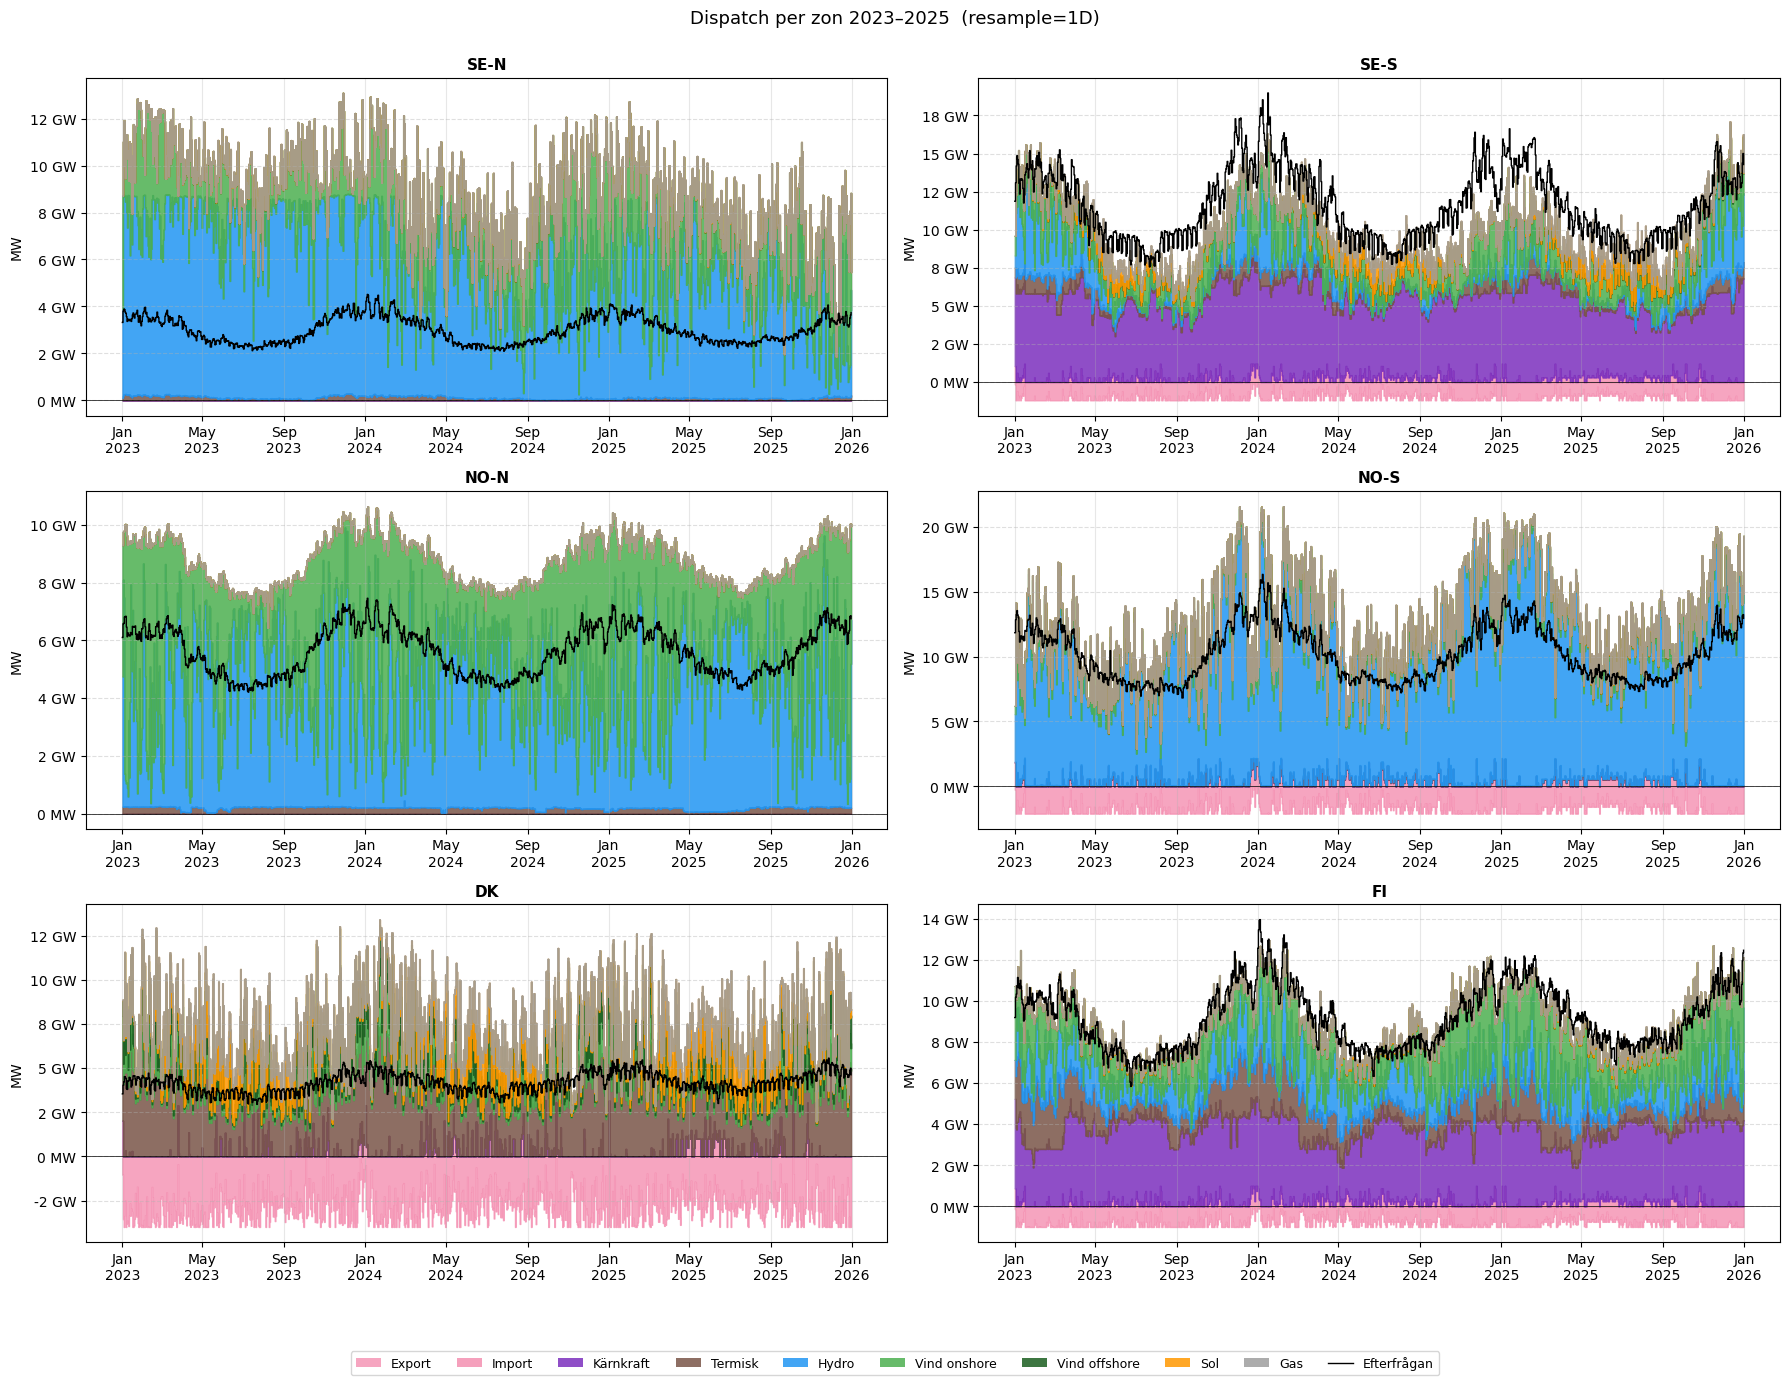

In [60]:
from scripts.plot_dispatch import build_zone_df, plot_zone, make_legend

RESAMPLE = '1D'   # ← ändra: None = rådata 3h, '1D' = dagsmedelv, '7D' = veckomedel

_data = dict(gen=dispatch, hydro=hydro_d)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
for ax, zone in zip(axes.flat, ZONES):
    df = build_zone_df(zone, _data, load)
    plot_zone(ax, df, zone, RESAMPLE)

carriers_all = set()
for zone in ZONES:
    carriers_all |= set(build_zone_df(zone, _data, load).columns)
make_legend(fig, carriers_all)

plt.suptitle(f'Dispatch per zon 2023–2025  (resample={RESAMPLE})', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])

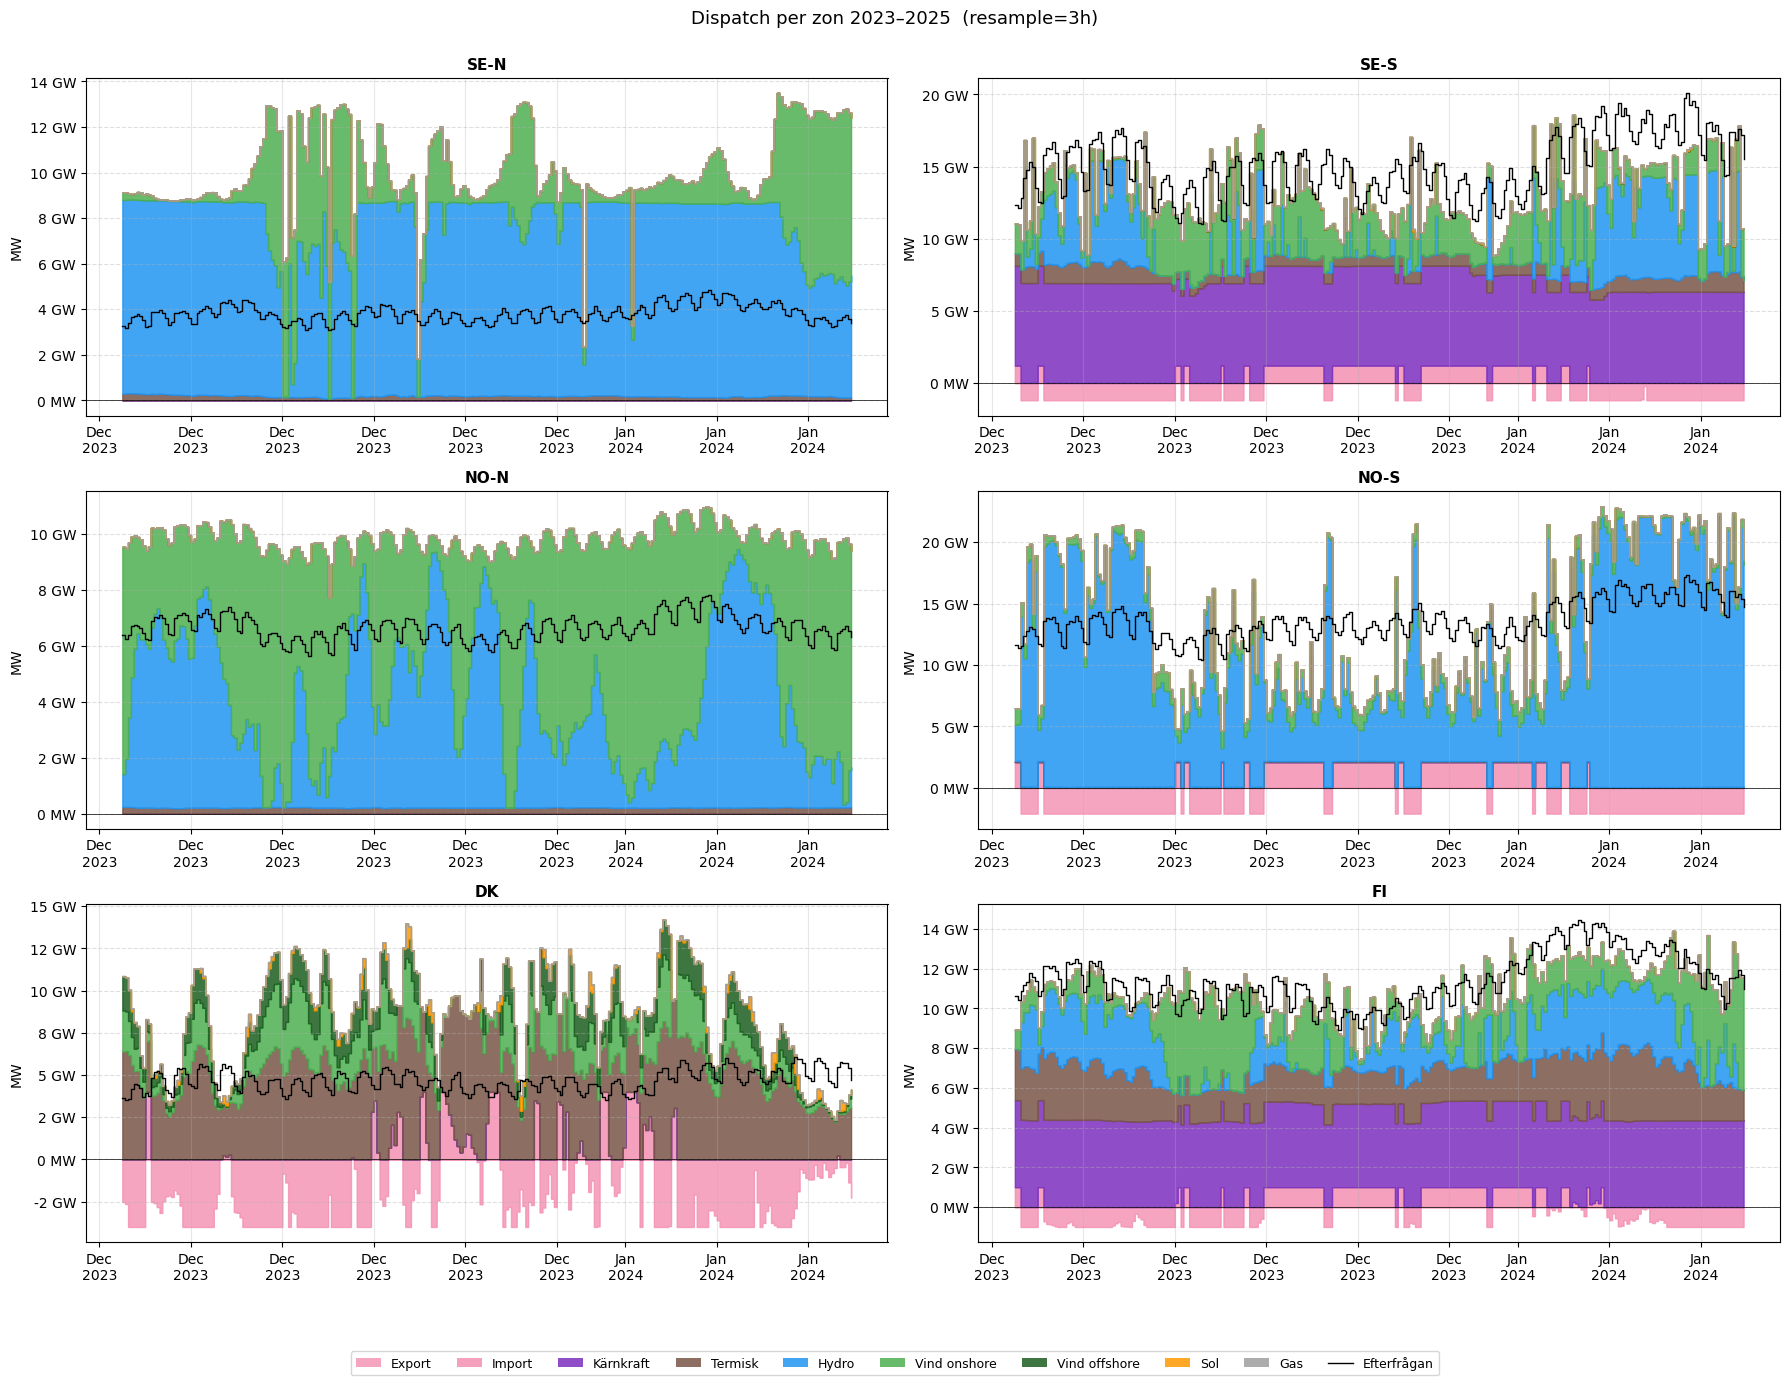

In [61]:
from scripts.plot_dispatch import build_zone_df, plot_zone, make_legend, COLORS, STACK_ORDER

RESAMPLE = '3h'   # ← ändra: None = rådata 3h, '1D' = dagsmedelv, '7D' = veckomedel

_data = dict(gen=dispatch, hydro=hydro_d)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
for ax, zone in zip(axes.flat, ZONES):
    df = build_zone_df(zone, _data, load).loc['2023-12-10':'2024-01-10']
    plot_zone(ax, df, zone, RESAMPLE)

carriers_all = set()
for zone in ZONES:
    carriers_all |= set(build_zone_df(zone, _data, load).columns)
make_legend(fig, carriers_all)

plt.suptitle(f'Dispatch per zon 2023–2025  (resample={RESAMPLE})', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])

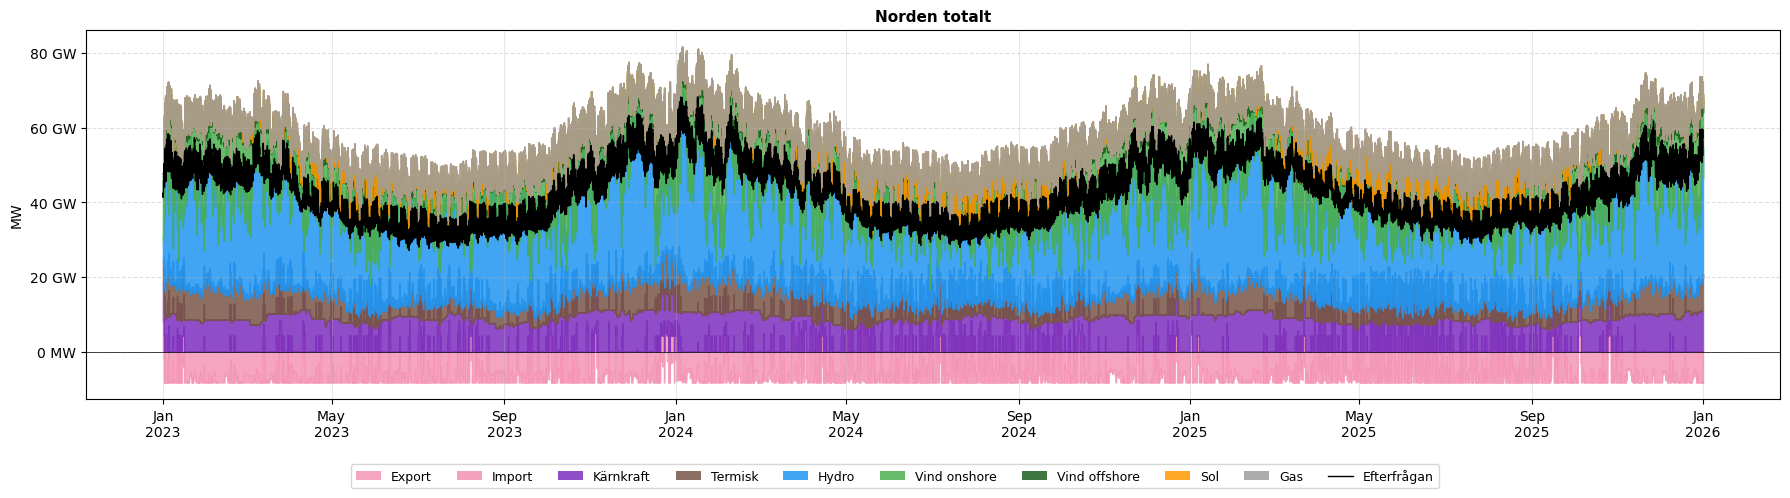

In [62]:
# Nordic total
nordic_df = pd.concat([build_zone_df(z, _data, load) for z in ZONES]).groupby(level=0).sum()

fig, ax = plt.subplots(figsize=(18, 5))
plot_zone(ax, nordic_df, 'Norden totalt', RESAMPLE)
make_legend(fig, set(nordic_df.columns))
plt.tight_layout(rect=[0, 0.08, 1, 1])

## 4. Nätverksflöden på länkarna

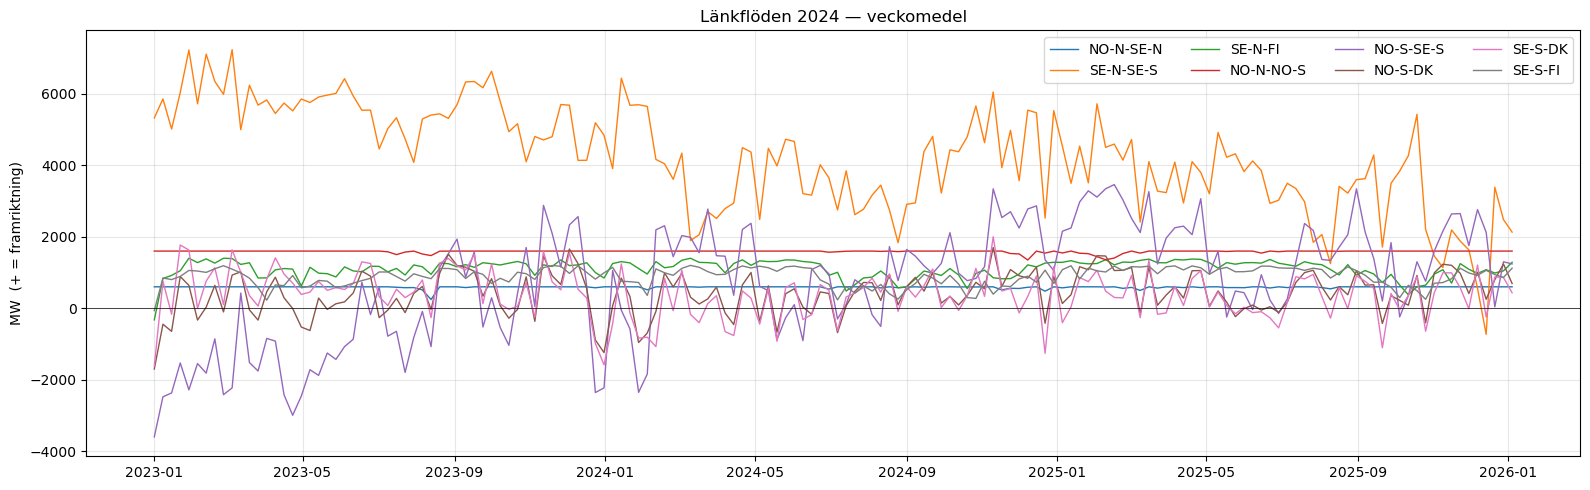

In [63]:
# Veckovis medelflöde per länk (positivt = z0→z1, negativt = z1→z0)
flows_w = flows.resample('W').mean()

fig, ax = plt.subplots(figsize=(16, 5))
for col in flows_w.columns:
    ax.plot(flows_w.index, flows_w[col], label=col, lw=1)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('MW  (+ = framriktning)')
ax.set_title('Länkflöden 2024 — veckomedel')
ax.legend(ncol=4)
plt.tight_layout()

In [64]:
# Kapacitetsutnyttjande per länk
link_caps = {}
for z0, z1, cap in cfg['links']:
    link_caps[f'{z0}-{z1}'] = cap

print('Länk             Cap(MW)   Max(MW)   Medel(MW)  Uttnyttj%')
print('-' * 62)
for link, cap in link_caps.items():
    if link in flows.columns:
        f = flows[link]
        print(f'{link:<18} {cap:>6.0f}    {f.abs().max():>7.0f}    {f.mean():>7.0f}    {f.abs().mean()/cap*100:>5.1f}%')

Länk             Cap(MW)   Max(MW)   Medel(MW)  Uttnyttj%
--------------------------------------------------------------
NO-N-SE-N             600        600        590     99.7%
SE-N-SE-S            7300       7300       4252     64.0%
SE-N-FI              1400       1400       1113     88.9%
NO-N-NO-S            1600       1600       1588     99.7%
NO-S-SE-S            3600       3600        745     80.7%
NO-S-DK              1700       1700        435     89.9%
SE-S-DK              2000       2000        400     85.1%
SE-S-FI              1200       1200        891     88.7%


## 5. Nordisk energibalans — modell vs verklighet

In [65]:
# Årsproduktion per källa och zon (TWh)
dt_h = (dispatch.index[1] - dispatch.index[0]).total_seconds() / 3600

rows = []
for zone in ZONES:
    row = {'zon': zone}
    for carrier in ['nuclear', 'thermal', 'hydro', 'wind_onshore', 'wind_offshore', 'solar', 'gas']:
        col = f'{zone} {carrier}' if carrier != 'hydro' else f'{zone} hydro'
        src = dispatch if carrier != 'hydro' else hydro_d
        row[carrier] = src.get(col, pd.Series(0, index=dispatch.index)).clip(lower=0).sum() * dt_h / 1e6
    row['import']   = dispatch.get(f'{zone} market', pd.Series(0, index=dispatch.index)).clip(lower=0).sum() * dt_h / 1e6
    row['export']   = dispatch.get(f'{zone} market', pd.Series(0, index=dispatch.index)).clip(upper=0).sum() * dt_h / 1e6
    row['load_twh'] = load[zone].sum() * dt_h / 1e6 if zone in load.columns else 0
    rows.append(row)

bal = pd.DataFrame(rows).set_index('zon')
bal['prod_twh']     = bal[['nuclear','thermal','hydro','wind_onshore','wind_offshore','solar','gas']].sum(axis=1)
bal['netto_export'] = -bal['export'] - bal['import']
bal.round(1)

,nuclear,thermal,hydro,wind_onshore,wind_offshore,solar,gas,import,export,load_twh,prod_twh,netto_export
zon,,,,,,,,,,,,
SE-N,0.0,2.9,160.5,66.7,0.0,0.3,0.0,0.0,0.0,78.6,230.5,-0.0
SE-S,140.2,15.0,37.7,47.1,0.3,12.4,0.0,5.6,-25.9,303.6,252.8,20.3
NO-N,0.0,5.1,123.3,102.7,0.0,0.0,0.0,0.0,0.0,147.6,231.2,-0.0
NO-S,0.0,1.8,299.6,16.0,0.0,0.7,0.0,9.9,-45.4,267.0,318.0,35.5
DK,0.0,98.8,0.0,29.2,25.3,28.8,0.0,7.5,-75.5,109.7,182.1,68.0
FI,95.1,36.8,41.6,56.5,0.0,1.2,0.0,4.7,-20.8,241.3,231.1,16.1


In [66]:
print('Norden totalt (2023–2025 sammanlagt, TWh):')
print(f"  Produktion:    {bal['prod_twh'].sum():.0f} TWh")
print(f"  Last:          {bal['load_twh'].sum():.0f} TWh")
print(f"  Netto export:  {bal['netto_export'].sum():.0f} TWh")
print()
print('Per källa:')
for col in ['hydro','nuclear','wind_onshore','wind_offshore','solar','thermal']:
    print(f"  {col:<16} {bal[col].sum():>7.0f} TWh")

Norden totalt (2023–2025 sammanlagt, TWh):
  Produktion:    1446 TWh
  Last:          1148 TWh
  Netto export:  140 TWh

Per källa:
  hydro                663 TWh
  nuclear              235 TWh
  wind_onshore         318 TWh
  wind_offshore         26 TWh
  solar                 43 TWh
  thermal              160 TWh


## 6. Vattenkraft — modell vs eSett faktisk

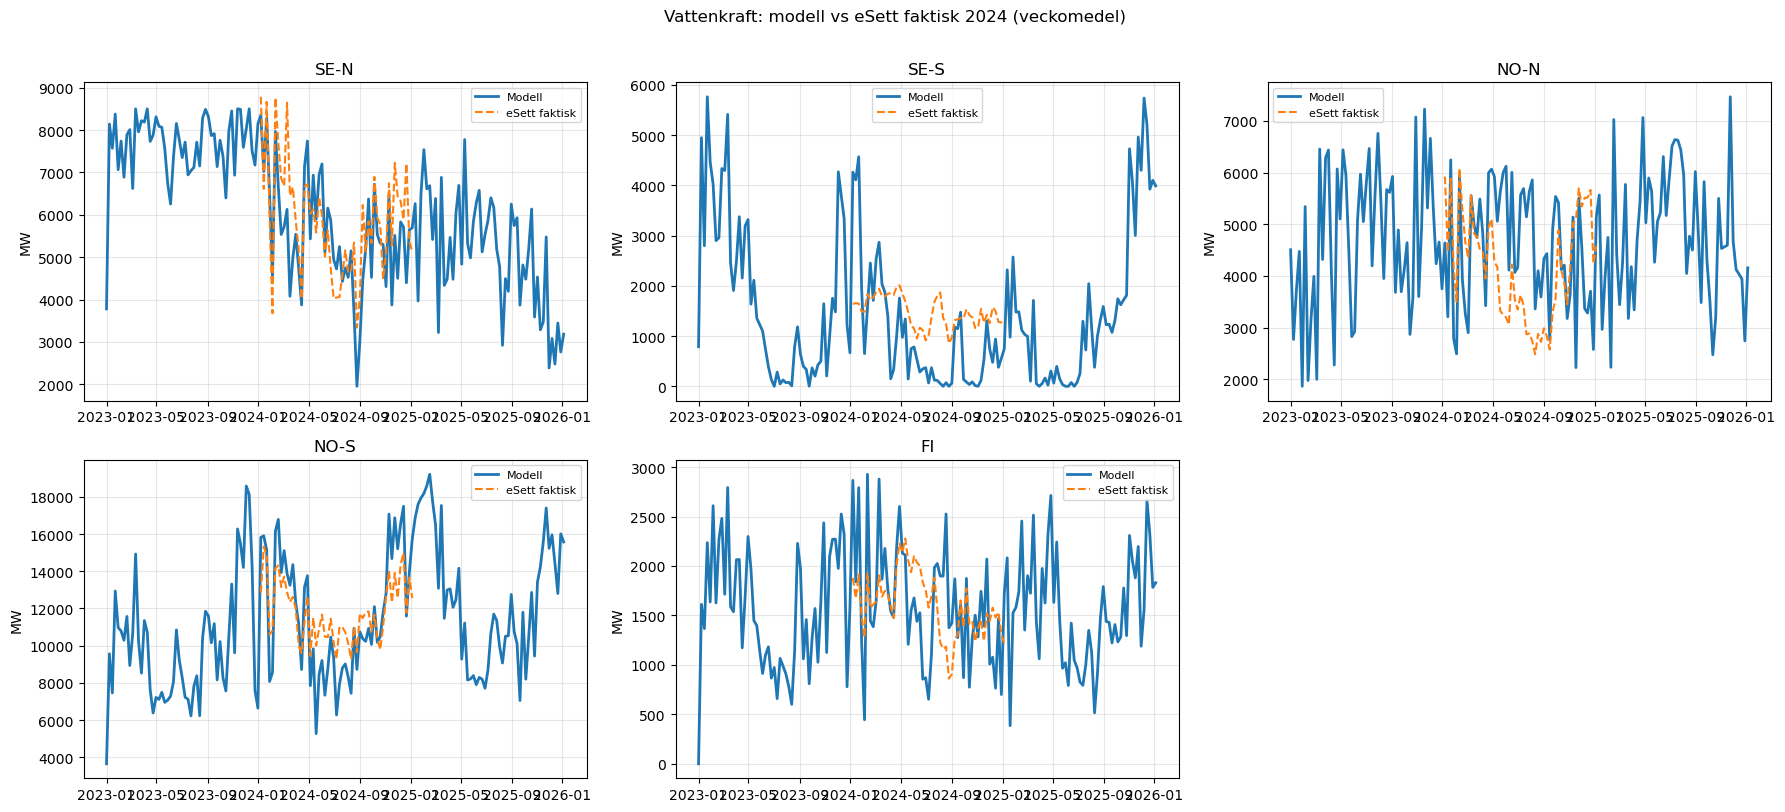

In [67]:
from nordpsa.hydro import load_actual_hydro

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for ax, zone in zip(axes.flat, [z for z in ZONES if cfg['zones'][z]['hydro_p_nom_mw'] > 0]):
    # Modell
    col = f'{zone} hydro'
    if col in hydro.columns:
        mod = hydro[col].resample('W').mean()
        ax.plot(mod.index, mod.values, label='Modell', lw=2)

    # Faktisk (eSett) — bara 2024
    from pathlib import Path as P
    raw = P('..') / 'data' / 'raw' / f'production_{zone}_2024.parquet'
    if raw.exists():
        df = pd.read_parquet(raw)
        df['timestampUTC'] = pd.to_datetime(df['timestampUTC'], utc=True).dt.tz_localize(None)
        actual = df.set_index('timestampUTC')['hydro'].resample('W').mean()
        ax.plot(actual.index, actual.values, label='eSett faktisk', lw=1.5, ls='--')

    ax.set_title(zone)
    ax.set_ylabel('MW')
    ax.legend(fontsize=8)

for ax in axes.flat[len([z for z in ZONES if cfg['zones'][z]['hydro_p_nom_mw'] > 0]):]:
    ax.set_visible(False)

plt.suptitle('Vattenkraft: modell vs eSett faktisk 2024 (veckomedel)', y=1.01)
plt.tight_layout()

## 7. Kapacitetsresultat (p_nom_opt)

In [68]:
# Optimal installerad kapacitet per teknik och zon
ext = n.generators[n.generators.p_nom_extendable].copy()
ext['p_nom_opt_mw'] = n.generators.p_nom_opt[ext.index]
ext['added_mw']     = (ext['p_nom_opt_mw'] - ext['p_nom_min']).clip(lower=0)

# Pivottabell: zoner × carriers
tbl = ext.pivot_table(values='p_nom_opt_mw', index='bus', columns='carrier', aggfunc='sum', fill_value=0)
tbl.index.name = 'zon'
print('Optimal kapacitet (MW):')
print(tbl.round(0).to_string())
print()
added = ext[ext['added_mw'] > 1][['carrier','p_nom_min','p_nom_opt_mw','added_mw']]
if added.empty:
    print('Ingen ny kapacitet byggd utöver befintlig.')
else:
    print('Ny kapacitet (utöver befintlig):')
    print(added.round(0).to_string())

Optimal kapacitet (MW):
carrier  gas  nuclear   solar  wind_offshore  wind_onshore
zon                                                       
DK       0.0      0.0  8507.0         2999.0        5454.0
FI       0.0   4400.0   474.0            0.0        8960.0
NO-N     0.0      0.0    18.0            0.0       13465.0
NO-S     0.0      0.0   291.0            0.0        2208.0
SE-N     0.0      0.0   117.0            0.0       10050.0
SE-S     0.0   6900.0  4369.0          159.0        7092.0

Ny kapacitet (utöver befintlig):
                        carrier  p_nom_min  p_nom_opt_mw  added_mw
name                                                              
SE-S solar                solar     2456.0        4369.0    1913.0
NO-N wind_onshore  wind_onshore     3468.0       13465.0    9997.0
DK solar                  solar     3024.0        8507.0    5483.0


## 8. Marknadsflöden mot kontinenten

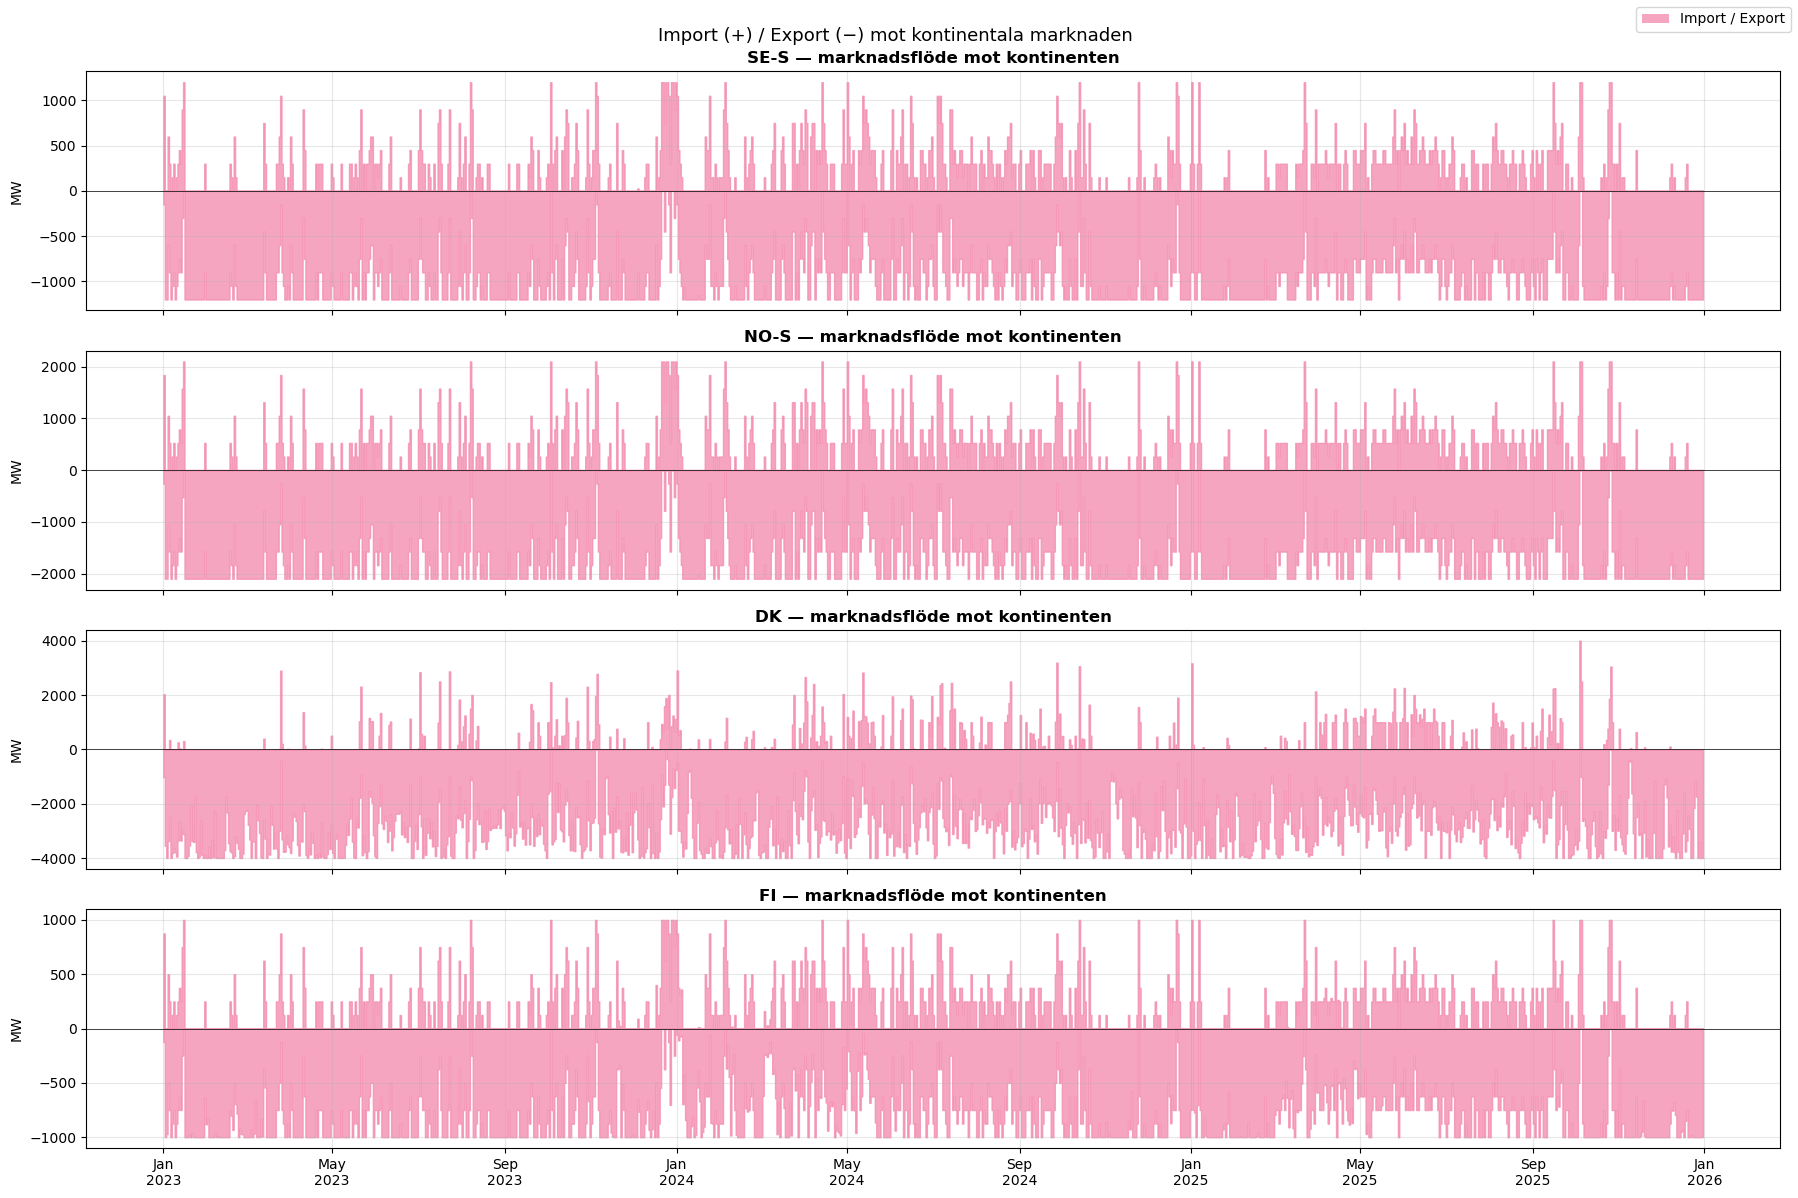

In [69]:
mkt_zones = [z for z in ZONES if f'{z} market' in dispatch.columns]
mkt_cols  = [f'{z} market' for z in mkt_zones]
mkt       = dispatch[mkt_cols].copy()
mkt.columns = mkt_zones

fig, axes = plt.subplots(len(mkt_zones), 1, figsize=(18, 3*len(mkt_zones)), sharex=True)
for ax, zone in zip(axes, mkt_zones):
    imp = mkt[zone].clip(lower=0).resample('1D').mean()
    exp = mkt[zone].clip(upper=0).resample('1D').mean()
    ax.fill_between(imp.index, imp, color='#F48FB1', alpha=0.8, label='Import', step='post')
    ax.fill_between(exp.index, exp, color='#F48FB1', alpha=0.8, label='Export', step='post')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{zone} — marknadsflöde mot kontinenten', fontweight='bold')
    ax.set_ylabel('MW')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

handles = [plt.Rectangle((0,0),1,1,fc='#F48FB1',alpha=0.8)]
fig.legend(handles, ['Import / Export'], loc='upper right')
plt.suptitle('Import (+) / Export (−) mot kontinentala marknaden', fontsize=13)
plt.tight_layout()

In [70]:
n.generators[['p_nom','p_nom_extendable','p_nom_min', 'p_nom_max', 'p_nom_set', 'p_min_pu', 'p_max_pu','marginal_cost','p_nom_opt']]

,p_nom,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,p_max_pu,marginal_cost,p_nom_opt
name,,,,,,,,,
SE-N slack,1000000.000000,False,0.0,inf,NaN,0.0,1.0,3000.0,1000000.000000
NO-N slack,1000000.000000,False,0.0,inf,NaN,0.0,1.0,3000.0,1000000.000000
SE-N thermal,306.574879,False,0.0,inf,NaN,0.0,1.0,0.0,306.574879
SE-S thermal,1841.577541,False,0.0,inf,NaN,0.0,1.0,0.0,1841.577541
NO-N thermal,741.979592,False,0.0,inf,NaN,0.0,1.0,0.0,741.979592
NO-S thermal,258.498090,False,0.0,inf,NaN,0.0,1.0,0.0,258.498090
DK thermal,8902.194886,False,0.0,inf,NaN,0.0,1.0,0.0,8902.194886
FI thermal,4130.451640,False,0.0,inf,NaN,0.0,1.0,0.0,4130.451640
SE-N nuclear,0.000000,True,0.0,20000.0,NaN,0.0,1.0,20.0,-0.000000


In [71]:
n.generators_t.p['SE-N wind_onshore']

snapshot
2023-01-01 00:00:00    4973.201034
2023-01-01 03:00:00    5015.003635
2023-01-01 06:00:00    5081.781610
2023-01-01 09:00:00    5028.836247
2023-01-01 12:00:00    4961.838206
                          ...     
2025-12-31 09:00:00     204.061709
2025-12-31 12:00:00     425.519969
2025-12-31 15:00:00    1919.292294
2025-12-31 18:00:00    3541.803396
2025-12-31 21:00:00    4043.786064
Name: SE-N wind_onshore, Length: 8768, dtype: float64

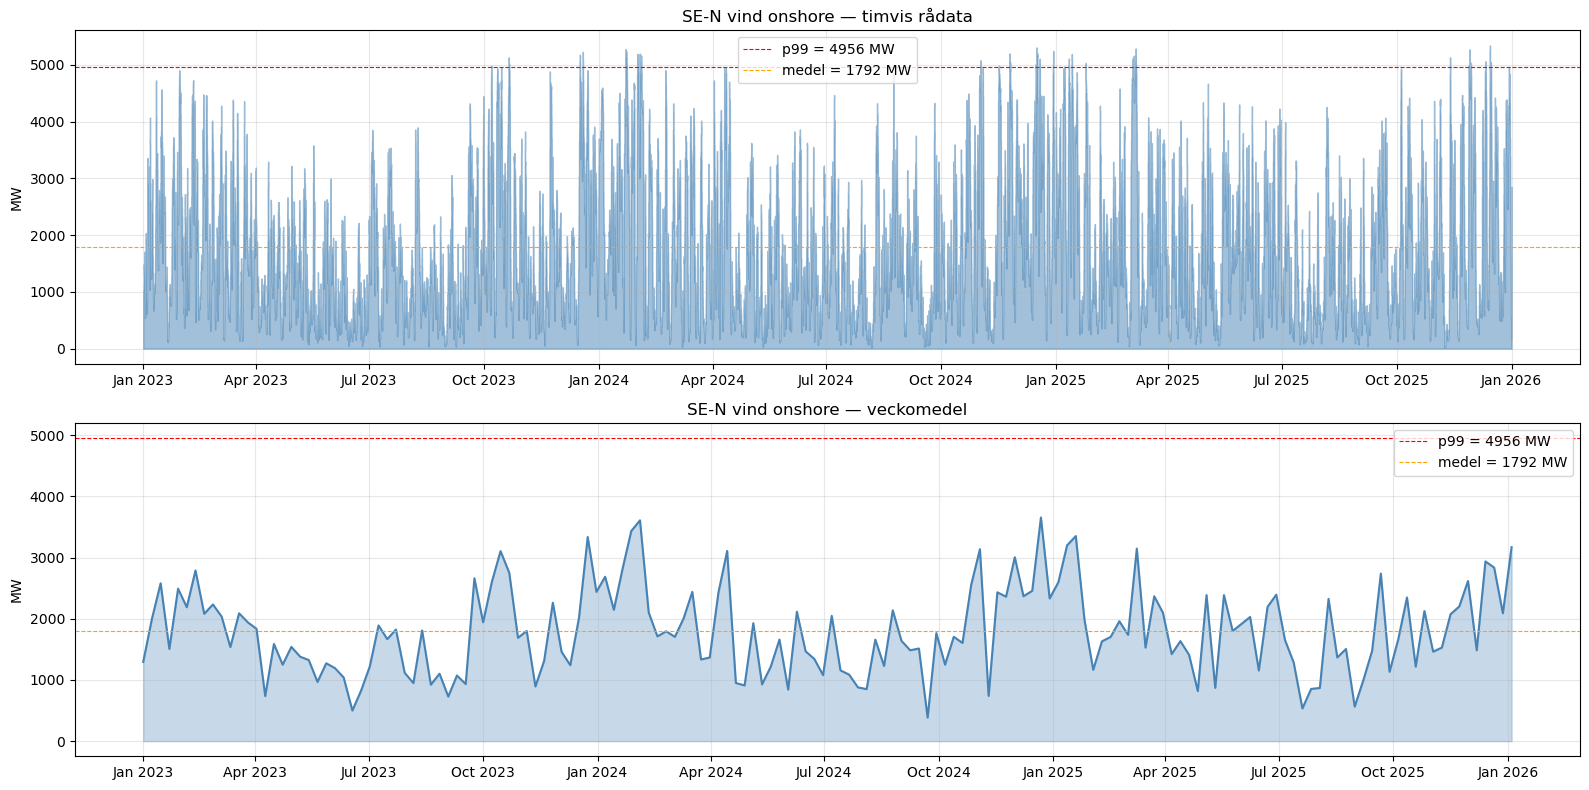

In [72]:
                             
import pandas as pd                                                                                                            
import numpy as np                                                                                                           
import matplotlib.pyplot as plt                                                                                                
import matplotlib.dates as mdates    
sel = "ra"                                                                                                                             
frames = [] 
if sel == "raw":
    for year in [2023, 2024, 2025]:        
        df = pd.read_parquet(ROOT / f'data/raw/production_SE-S_{year}.parquet')
        df['timestampUTC'] = pd.to_datetime(df['timestampUTC'], utc=True)
        frames.append(df.set_index('timestampUTC'))
        df = pd.concat(frames).sort_index()
    wind = df['wind'].fillna(0)
else:
    for year in [2023, 2024, 2025]:        
        df = n.generators_t.p.loc[str(year),'SE-S wind_onshore']
        frames.append(df)
        df = pd.concat(frames).sort_index()
    wind = df.fillna(0)

wind_w = wind.resample('W').mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].fill_between(wind.index, wind.values, alpha=0.5, color='steelblue', step='post')
axes[0].set_ylabel('MW')
axes[0].set_title('SE-N vind onshore — timvis rådata')

axes[1].plot(wind_w.index, wind_w.values, color='steelblue', lw=1.5)
axes[1].fill_between(wind_w.index, wind_w.values, alpha=0.3, color='steelblue')
axes[1].set_ylabel('MW')
axes[1].set_title('SE-N vind onshore — veckomedel')

for ax in axes:
  ax.grid(True, alpha=0.3)
  ax.axhline(np.percentile(wind, 99), color='red', ls='--', lw=0.8, label=f"p99 = {np.percentile(wind,99):.0f} MW")
  ax.axhline(wind.mean(), color='orange', ls='--', lw=0.8, label=f"medel = {wind.mean():.0f} MW")
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
  ax.legend()

plt.tight_layout()
